# 3. Strategy C data: crypto prices and funding rates

**Perpetual futures** never expire. To keep their price close to spot, longs and shorts pay each other a **funding rate** every 8 hours. Positive funding = longs pay shorts = crowded leveraged long demand. This is the crypto analogue of an interest-rate differential.

Source: Binance public data archive (data.binance.vision), USDT-margined perpetuals, 2020-01 to 2026-08. 12 coins including **LUNA and FTT** (collapsed in 2022) to avoid survivorship bias, plus **USDC** as a sanity check.

By default we load `data/clean/`. Set `DOWNLOAD = True` to re-download (about 2,000 small files; cached in `data/raw/binance/`).

## What this notebook does

**Purpose.** Prepare and check the crypto data for Strategy C. Perpetual futures pay a **funding rate** between longs and shorts every 8 hours; positive funding means leveraged buyers pay to hold their longs. This is the crypto version of an interest-rate differential, and the signal Strategy C trades on.

**Data.** Binance public data archive (data.binance.vision), USDT-margined perpetual futures, monthly zip files from 2020-01 to 2026-08:
- daily candles: closing price and traded volume in USDT;
- funding rate payments (every 8 hours).

**Coins.** BTC, ETH, BNB, XRP, ADA, DOGE, SOL, LTC, LINK, AVAX, plus **LUNA and FTT**, which collapsed in 2022 and are kept to avoid survivorship bias, plus **USDC**, a stablecoin used only as a sanity check.

**Steps (in `code/03_download_data_strategyC.py`)**
1. Download one zip per coin, per month and per data type; months before a coin existed return "not found" and are cached as empty files, so re-runs are fast.
2. Read each file (older files have no header row; newer ones use microsecond timestamps).
3. Build three daily tables: closing price, traded volume, and the sum of the funding rates paid each day.
4. Sanity checks: average funding per coin, USDC behaviour, delisting dates, and a per-coin summary.

**Outputs** in `data/clean/`: `crypto_close_daily.csv`, `crypto_quote_volume_daily.csv`, `crypto_funding_daily.csv`. Steps 1-3 run only when `DOWNLOAD = True`.

In [1]:
# Setup: run everything from the project root so the scripts' relative paths work
import os, importlib.util
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
%matplotlib inline

def load_script(path, name):
    """Import a numbered script from code/ (file names starting with a digit can't be imported normally)."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

Working directory: /Users/reza/Desktop/mfe-term_3/currency_market/currency-crypto-carry


In [2]:
DOWNLOAD = False   # True = re-download from data.binance.vision and rebuild data/clean

In [3]:
C3 = load_script("code/03_download_data_strategyC.py", "dataC")
print("Coins:", [s.replace("USDT", "") for s in C3.SYMBOLS])
if DOWNLOAD:
    C3.main()
else:
    print("Using the committed data in data/clean/ (set DOWNLOAD = True to rebuild)")

Coins: ['BTC', 'ETH', 'BNB', 'XRP', 'ADA', 'DOGE', 'SOL', 'LTC', 'LINK', 'AVAX', 'LUNA', 'FTT', 'USDC']
Using the committed data in data/clean/ (set DOWNLOAD = True to rebuild)


## Step 1 - load the cleaned data

In [4]:
close = pd.read_csv("data/clean/crypto_close_daily.csv", index_col=0, parse_dates=True)
volume = pd.read_csv("data/clean/crypto_quote_volume_daily.csv", index_col=0, parse_dates=True)
funding = pd.read_csv("data/clean/crypto_funding_daily.csv", index_col=0, parse_dates=True)
pd.DataFrame({"first price": close.apply(lambda s: s.first_valid_index().date()),
              "last price": close.apply(lambda s: s.last_valid_index().date()),
              "days": close.count(),
              "avg funding (% p.a.)": (100 * 365 * funding.mean()).round(1)})

,first price,last price,days,avg funding (% p.a.)
BTC,2020-01-01,2026-08-31,2435,11.8
ETH,2020-01-01,2026-08-31,2435,13.9
BNB,2020-02-10,2026-08-31,2395,-0.1
XRP,2020-01-06,2026-08-31,2425,14.7
ADA,2020-01-31,2026-08-31,2405,13.6
DOGE,2020-07-10,2026-08-31,2244,12.4
SOL,2020-09-14,2026-08-31,2173,0.2
LTC,2020-01-09,2026-08-31,2422,14.9
LINK,2020-01-17,2026-08-31,2419,13.8
AVAX,2020-09-23,2026-08-31,2169,6.9


## Step 2 - sanity checks
**USDC** is a stablecoin: its price should stay near 1 and its funding near 0.

In [5]:
print(f"USDC price range: {close['USDC'].min():.4f} to {close['USDC'].max():.4f}")
print(f"USDC average funding: {100 * 365 * funding['USDC'].mean():.2f}% p.a.")

USDC price range: 0.9845 to 1.0017
USDC average funding: 0.04% p.a.


**Delisted coins.** After FTX collapsed, Binance's archive keeps showing FTT with a frozen price and zero volume. The backtest therefore treats a coin as tradable only on days with a price **and** positive volume.

In [6]:
last_traded = volume.gt(0).apply(lambda s: s[s].index.max().date())
last_price = close.apply(lambda s: s.last_valid_index().date())
pd.DataFrame({"last day with volume": last_traded, "last price in file": last_price}).loc[["LUNA", "FTT", "BTC"]]

,last day with volume,last price in file
LUNA,2022-05-12,2022-05-13
FTT,2022-11-14,2026-08-31
BTC,2026-08-31,2026-08-31


## Step 3 - funding rates over time (30-day average, annualised)

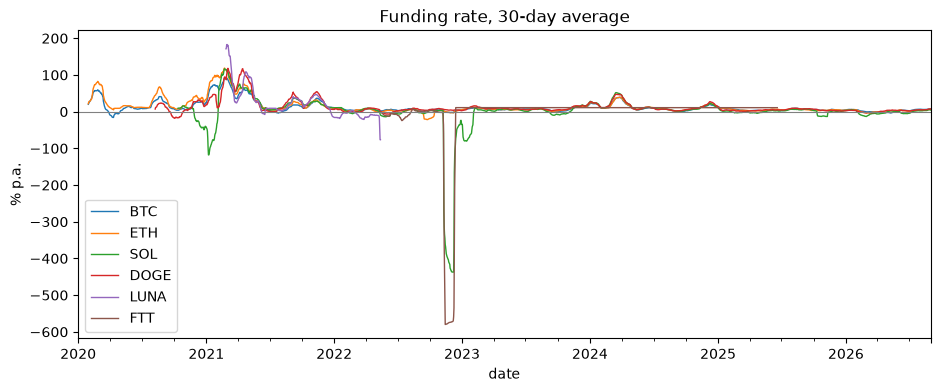

In [7]:
ax = (100 * 365 * funding[["BTC", "ETH", "SOL", "DOGE", "LUNA", "FTT"]].rolling(30).mean()).plot(figsize=(11, 4), lw=1)
ax.axhline(0, color="grey", lw=0.8); ax.set_ylabel("% p.a."); ax.set_title("Funding rate, 30-day average"); plt.show()

## Step 4 - per-coin summary
The same table the risk script saves (`output/risk/C_coin_summary.csv`), computed only over days each coin traded.

In [8]:
R = load_script("code/05_risk_analysis.py", "risk")
C = R.load_strategy_c()
c_close, c_vol, c_fund = C.load()
R.coin_summary(c_close, c_vol, c_fund).round(2)

,first,last traded,days,data after last trade (days),avg funding (% p.a.),positive funding days (%),ann. return (%),ann. vol (%),max drawdown (%),worst day (%),worst day,avg volume ($M),corr with BTC
BTC,2020-01-01,2026-08-31,2435,0,11.797656,87.679671,43.103768,60.636553,-76.669562,-39.979643,2020-03-12,13100.739765,1.0
ETH,2020-01-01,2026-08-31,2435,0,13.946962,88.049281,55.367108,81.497793,-79.351308,-45.223551,2020-03-12,7785.221394,0.822066
BNB,2020-02-10,2026-08-31,2395,0,-0.089163,34.906054,65.710047,83.27065,-70.929159,-44.084142,2020-03-12,608.5203,0.669715
XRP,2020-01-06,2026-08-31,2430,0,14.699747,80.90535,31.530745,103.506264,-83.290726,-41.868823,2020-12-23,1096.585515,0.578405
ADA,2020-01-31,2026-08-31,2405,0,13.55148,80.678527,21.833238,100.775815,-95.156724,-41.290648,2020-03-12,460.091286,0.672195
DOGE,2020-07-10,2026-08-31,2244,0,12.437085,83.68984,67.066022,199.502373,-92.354545,-38.997014,2021-01-30,973.945853,0.381977
SOL,2020-09-14,2026-08-31,2178,0,0.174016,71.225333,78.358161,114.09503,-96.27849,-50.881612,2022-11-09,1969.236075,0.579706
LTC,2020-01-09,2026-08-31,2427,0,14.87879,85.249279,1.234319,86.873797,-89.472058,-38.938053,2020-03-12,306.320028,0.736683
LINK,2020-01-17,2026-08-31,2419,0,13.830143,85.655229,24.176247,103.82823,-90.195179,-47.758847,2020-03-12,331.841036,0.676493
AVAX,2020-09-23,2026-08-31,2169,0,6.867598,69.493088,12.914808,114.722297,-95.633285,-37.894281,2021-05-19,340.308108,0.602548


## Questions this notebook answers, and results

**1. How much history do we have?** Prices start between 2020-01 (BTC, ETH) and 2020-09 (SOL, AVAX) and run to 2026-08-31. LUNA covers 2021-01-28 to 2022-05-13; FTT's archive starts only in 2022-04; USDC starts 2023-03-12.

**2. How big is the crypto "interest rate"?** Funding averages roughly **12-15% a year** on the main coins: BTC 11.8%, DOGE 12.4%, ADA 13.6%, LINK 13.8%, ETH 13.9%, XRP 14.7%, LTC 14.9%. It is positive on 81-88% of days. BNB (-0.1%) and SOL (0.2%) are close to zero and AVAX is 6.9%. LUNA had the highest funding, 22.1%, before it collapsed.

**3. Is the data clean?**
- **USDC passes the sanity check:** price between 0.9845 and 1.0017, average funding 0.04% a year.
- **Delisted coins need care:** LUNA's last day with volume is 2022-05-12. FTT's last is 2022-11-14 (the FTX collapse), but the archive keeps listing FTT until 2026-08-31 with a frozen price and zero volume. The backtest therefore trades a coin only on days with a price *and* positive volume. Over its 214 traded days FTT's funding averaged **-84% a year** (driven by the FTX collapse), not the -6.6% shown for the whole file, and the frozen data after 2022-11-14 covers 1,386 days.

**4. How risky are these coins?** Very. Annual volatility is 61% (BTC) to 200% (DOGE). Maximum drawdowns are -71% to -96% (and -99.99% for LUNA). Most worst days fell on 2020-03-12 (Covid crash). Daily returns are highly correlated with BTC (0.58-0.82 for most coins; DOGE 0.38).

**Limitations**
- Only about 6.5 years of data and 12 tradable coins.
- FTT's history before 2022-04 is missing from the archive.
- A few days in Feb/Apr 2022 are missing for some coins in Binance's archive; the backtest fills only those days.
- One exchange only (Binance); funding on other venues can differ.